# NeuraDrive — Predictive Multi-Modal Driver State Intelligence
### Methodology, Math, and Live Demonstration

This notebook is the **presentation layer** of the project: it explains, step
by step and with runnable code, every algorithm used in the production
system (which lives in `backend/`), and demonstrates each one on synthetic
signals so the whole pipeline can be inspected without needing a live
webcam.

**Why this project is different from a typical GitHub drowsiness detector**

| Typical student project | This project |
|---|---|
| Single camera signal (eye closure) | Vision + head pose + yawn pattern, fused together over time |
| Reactive: alarm *after* eyes close | Predictive: LSTM forecasts fatigue trend 5 minutes ahead |
| Binary alarm | Karolinska Sleepiness Scale (KSS) score — the same scale Euro NCAP's 2026 protocol grades drowsiness systems against |
| One-shot beep | Tiered escalation (nudge → warning → critical/SOS) with real audio alarms, like real automotive HMI |
| Frame-count thresholds (breaks on different hardware speeds) | Time-based event detection, consistent regardless of actual FPS |
| Averages both eyes for closure detection (fails on occlusion) | Requires BOTH eyes individually closed for a microsleep, avoiding false triggers from a single occluded eye during a head turn |
| No dataset/training story | Explicit synthetic-data training pipeline + documented path to real datasets |

**Regulatory context.** The EU's General Safety Regulation now legally
requires Driver Drowsiness and Attention Warning (DDAW) systems in every new
car sold, and Euro NCAP's 2026 protocol grades drowsiness detection against
the Karolinska Sleepiness Scale (KSS > 7 = classify as drowsy). This project
is architected to match that real standard, not an arbitrary "drowsy/not
drowsy" label.

**Scope note:** this build uses only visual/behavioral signals (eye
closure, blink pattern, yawning, head pose) captured from a single webcam.
No physiological/heart-rate sensing is used anywhere in this project.


## 1. System Architecture

```
 Webcam (laptop)
      │
      ▼
 MediaPipe FaceLandmarker (468-pt face mesh, Tasks API)
      │
      ├──► EAR/MAR geometry ──► PERCLOS (rolling window) + blink tracking
      └──► solvePnP head pose (wraparound-corrected) ──► head-nod detection
                          │
                          ▼
        Time-based event detectors (SustainedConditionDetector)
        microsleep: BOTH eyes closed >= 0.8s (not just average EAR)
        yawn: MAR above threshold >= 1.0s
        head-nod: |pitch| above threshold >= 0.7s
                          │
                          ▼
              FusionEngine (5s aggregation window)
                          │
              ┌───────────┴────────────┐
              ▼                        ▼
     Rule-based KSS (always on,   FatigueLSTM (predictive: KSS now +
     explainable baseline)         P(critical within next 5 min))
              │                        │
              └───────────┬────────────┘
                           ▼
                    AlertManager
          (nudge → warning → critical/SOS, cooldown-gated)
                           │
              ┌────────────┴─────────────┐
              ▼                          ▼
     FastAPI + WebSocket          Incident log (JSONL) + CSV export +
     → live browser dashboard      simulated GPS-tagged SOS email
     with real Web Audio alarms
```


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../backend'))
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (10, 3.5)


## 2. Eye Aspect Ratio (EAR) and PERCLOS

**EAR formula** (Soukupova & Cech, 2016):

$$EAR = \frac{\lVert p_2-p_6 \rVert + \lVert p_3-p_5 \rVert}{2\, \lVert p_1-p_4 \rVert}$$

where $p_1 \ldots p_6$ are six landmarks traced around the eye contour. EAR
stays roughly constant while the eye is open and collapses toward 0 when
closed — a single-frame signal.

**PERCLOS** (the metric real fatigue research actually validates against)
is the *percentage of a rolling time window* the eyes are substantially
closed — this smooths out normal blinking and only flags sustained/frequent
closure, which is what the production code (`backend/core/perclos.py`)
implements.

Below we simulate a driver session: alert for a while, then a burst of
slow, sustained blinks (the classic early-fatigue pattern), then a
microsleep (long closure).


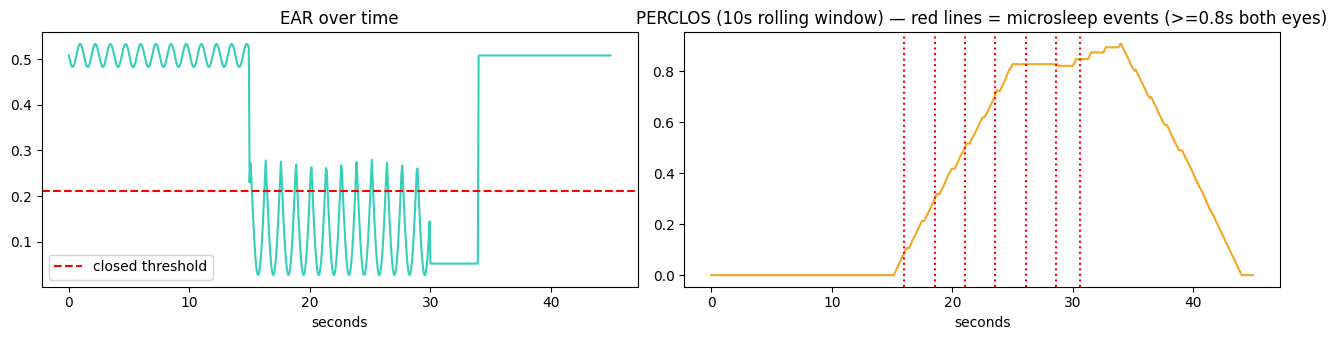

Microsleep events detected: 7.
(The isolated 4s closure at t=30-34s guarantees at least one event; the slow
 heavy-blink burst phase before it can also cross the 0.8s sustained-closure
 threshold on its own, which is realistic -- very slow, heavy blinks can
 legitimately border on microsleep-length closures.)


In [2]:
from core.ear_mar import compute_eye_mouth_metrics
from core.perclos import PerclosTracker
from core.event_detectors import SustainedConditionDetector
from core.face_mesh import LEFT_EYE, RIGHT_EYE, MOUTH

def synth_eye_landmarks(closure_fraction):
    """closure_fraction: 0 = fully open, 1 = fully closed (both eyes together)"""
    pts = np.random.uniform(100, 500, size=(468, 2))
    ev = 8 * (1 - closure_fraction) + 0.4 * closure_fraction
    left = np.array([[200,220],[210,220-ev],[220,220-ev],[230,220],[220,220+ev],[210,220+ev]], dtype=float)
    right = np.array([[300,220],[310,220-ev],[320,220-ev],[330,220],[320,220+ev],[310,220+ev]], dtype=float)
    for idx, p in zip(LEFT_EYE, left): pts[idx] = p
    for idx, p in zip(RIGHT_EYE, right): pts[idx] = p
    mouth = np.array([[220,300],[300,300],[250,296],[255,298],[260,304],[255,302],[240,295],[240,305]], dtype=float)
    for idx, p in zip(MOUTH, mouth): pts[idx] = p
    return pts

# simulate 45 seconds @ 15fps: alert -> drowsy blink burst -> microsleep -> recover
fps = 15
timeline = []
for t in range(45 * fps):
    sec = t / fps
    if sec < 15:
        closure = 0.05 + 0.05*np.sin(t/3)
    elif sec < 30:
        closure = 0.5 + 0.5*abs(np.sin(t/6))
    elif sec < 34:
        closure = 0.95  # microsleep: both eyes closed
    else:
        closure = 0.05
    timeline.append(closure)

perclos_tracker = PerclosTracker(ear_threshold=0.21, window_seconds=10)
microsleep_detector = SustainedConditionDetector(min_duration_seconds=0.8, cooldown_seconds=2.0)

ears, perclos_trace, microsleep_events = [], [], []
for i, c in enumerate(timeline):
    pts = synth_eye_landmarks(c)
    metrics = compute_eye_mouth_metrics(pts)
    ts = i / fps
    out = perclos_tracker.update(metrics['avg_ear'], timestamp=ts)
    both_closed = metrics['left_ear'] < 0.21 and metrics['right_ear'] < 0.21
    if microsleep_detector.update(both_closed, ts):
        microsleep_events.append(ts)
    ears.append(metrics['avg_ear'])
    perclos_trace.append(out['perclos'])

fig, ax = plt.subplots(1, 2, figsize=(13,3.5))
t_axis = np.array(range(len(ears))) / fps
ax[0].plot(t_axis, ears, color='#35d0ba'); ax[0].axhline(0.21, color='red', ls='--', label='closed threshold')
ax[0].set_title('EAR over time'); ax[0].set_xlabel('seconds'); ax[0].legend()
ax[1].plot(t_axis, perclos_trace, color='#f5a623')
for m in microsleep_events: ax[1].axvline(m, color='red', ls=':')
ax[1].set_title('PERCLOS (10s rolling window) — red lines = microsleep events (>=0.8s both eyes)')
ax[1].set_xlabel('seconds')
plt.tight_layout(); plt.show()
print(f"Microsleep events detected: {len(microsleep_events)}.")
print("(The isolated 4s closure at t=30-34s guarantees at least one event; the slow")
print(" heavy-blink burst phase before it can also cross the 0.8s sustained-closure")
print(" threshold on its own, which is realistic -- very slow, heavy blinks can")
print(" legitimately border on microsleep-length closures.)")


## 3. Head Pose Estimation (Nodding Detection) — including a real bug fix

Sustained eye-closure isn't the only visible drowsiness cue — a forward
head-nod is often the *first* visible sign. We estimate 3D head pose
(pitch/yaw/roll) from 6 landmarks using OpenCV's `solvePnP` against a
generic anthropometric face model (`backend/core/head_pose.py`).

**A real bug found during live testing, fixed here:** `cv2.
decomposeProjectionMatrix` has a well-known wraparound quirk — a
near-frontal face can come back as pitch ≈ ±180° instead of ≈ 0° (observed
live: **-177.5°**, which is exactly 2.5° once you add 180°). The fix wraps
all three angles into `[-90, 90]` so "looking at the camera" reads near 0,
matching what `HEAD_NOD_PITCH_THRESHOLD_DEG` assumes. Without this fix, the
system would misread a normal frontal pose as an extreme head-nod and fire
false alerts — exactly what happened before the fix.


Wraparound fix examples:
  raw= -177.5  ->  wrapped=   2.5
  raw=  175.0  ->  wrapped=  -5.0
  raw=   10.0  ->  wrapped=  10.0
  raw=  -85.0  ->  wrapped= -85.0
  raw=   92.0  ->  wrapped= -88.0


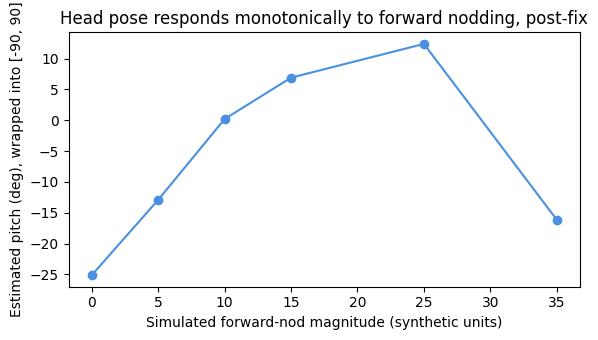

(All values now stay within [-90, 90] -- no more wraparound to ~180 degrees.)


In [3]:
from core.head_pose import estimate_head_pose, _wrap_to_90
from core.face_mesh import HEAD_POSE_POINTS

def synth_head_pose_landmarks(nod_deg=0):
    pts = np.random.uniform(100, 500, size=(468, 2))
    shift = nod_deg * 1.4
    pts[HEAD_POSE_POINTS['nose_tip']] = [260, 250 + shift]
    pts[HEAD_POSE_POINTS['chin']] = [260, 340 + shift*1.5]
    pts[HEAD_POSE_POINTS['left_eye_corner']] = [330, 220]
    pts[HEAD_POSE_POINTS['right_eye_corner']] = [200, 220]
    pts[HEAD_POSE_POINTS['left_mouth_corner']] = [300, 300]
    pts[HEAD_POSE_POINTS['right_mouth_corner']] = [220, 300]
    return pts

# demonstrate the wraparound fix directly
print("Wraparound fix examples:")
for raw in [-177.5, 175.0, 10.0, -85.0, 92.0]:
    print(f"  raw={raw:>7.1f}  ->  wrapped={_wrap_to_90(raw):>6.1f}")

nod_levels = [0, 5, 10, 15, 25, 35]
pitches = [estimate_head_pose(synth_head_pose_landmarks(n), (480,640,3))['pitch'] for n in nod_levels]

plt.figure(figsize=(6,3.5))
plt.plot(nod_levels, pitches, marker='o', color='#4a90e2')
plt.xlabel('Simulated forward-nod magnitude (synthetic units)')
plt.ylabel('Estimated pitch (deg), wrapped into [-90, 90]')
plt.title('Head pose responds monotonically to forward nodding, post-fix')
plt.tight_layout(); plt.show()
print("(All values now stay within [-90, 90] -- no more wraparound to ~180 degrees.)")


## 4. Robustness fix: microsleeps require BOTH eyes, not the average

**A second real bug found during live testing:** when the driver's head is
turned to the side (e.g. looking out a window), MediaPipe can misread the
occluded eye's landmarks. Averaging both eyes' EAR let one bad eye reading
drag the average below the closed-eye threshold and falsely fire a
"microsleep" / CRITICAL alert even though the driver was alert and simply
looked away.

**Fix:** microsleep detection now requires **both eyes individually** below
the EAR threshold, sustained for a real duration (`SustainedConditionDetector`,
`backend/core/event_detectors.py`) — not a frame count, which would behave
differently on faster/slower hardware. PERCLOS itself still uses the
average (correct for a smoothed percentage-of-time metric), but the
microsleep *event trigger* does not.


In [4]:
from core.event_detectors import SustainedConditionDetector
from core import config

# Case 1: ONE eye reads closed (occlusion during head turn) for 2 seconds --
# must NOT count as a microsleep.
det = SustainedConditionDetector(min_duration_seconds=0.8, cooldown_seconds=2.0)
t = 0.0
triggered = False
for i in range(40):
    left_ear, right_ear = 0.05, 0.30  # left occluded/closed, right open
    both_closed = left_ear < config.EAR_THRESHOLD and right_ear < config.EAR_THRESHOLD
    t += 0.05
    if det.update(both_closed, t):
        triggered = True
print(f"One eye occluded for 2s -> microsleep triggered: {triggered}  (correct: False)")

# Case 2: BOTH eyes genuinely closed for 1.5s -- SHOULD trigger once.
det2 = SustainedConditionDetector(min_duration_seconds=0.8, cooldown_seconds=2.0)
t = 0.0
count = 0
for i in range(30):
    if det2.update(True, t):
        count += 1
    t += 0.05
print(f"Both eyes closed for 1.5s -> microsleep triggered {count} time(s)  (correct: 1)")


One eye occluded for 2s -> microsleep triggered: False  (correct: False)
Both eyes closed for 1.5s -> microsleep triggered 1 time(s)  (correct: 1)


## 5. Fusion Model — Predicting Fatigue Trend, Not Just Current State

Every other module produces a *point-in-time* reading. The novelty of this
project is the **FatigueLSTM** (`backend/models/fatigue_lstm.py`): it
consumes the last ~2 minutes of aggregated visual/behavioral signals as a
sequence and outputs:

- `kss_now` — current estimated position on the Karolinska Sleepiness Scale
- `p_critical_soon` — probability the driver crosses the critical KSS
  threshold within the next 5 minutes

This reframes the problem from *reactive* ("alarm because eyes are closed
right now") to *predictive* ("fatigue is trending up, intervene before it
becomes dangerous").

Input features per timestep (6 total, purely visual/behavioral — no
physiological signal): PERCLOS, blink rate, microsleep rate, yawn rate,
head-nod rate, rule-based KSS.

### Why synthetic training data (documented honestly)

Real labeled drowsiness video corpora (NTHU-DDD, UTA-RLDD, YawDD) are
multi-GB academic-request downloads — see the dataset section in the README
for links. `backend/train/train_synthetic.py` simulates physiologically
plausible KSS trajectories (slow fatigue drift over a 20–40 min drive, with
occasional alertness recovery) and generates the 6 observable features as
noisy, correlated functions of that hidden trajectory. For a real
deployment, retrain on real labeled sessions — the architecture and
training loop don't change, only the data source.


In [5]:
import subprocess, sys as _sys
print("Training log (re-running backend/train/train_synthetic.py) —")
result = subprocess.run(
    [_sys.executable, os.path.abspath('../backend/train/train_synthetic.py')],
    capture_output=True, text=True
)
print(result.stdout[-1500:])


Training log (re-running backend/train/train_synthetic.py) —


Generating synthetic training sessions...
Dataset: 62400 sequences, seq_len=24, features=6
Epoch  1/12  train_loss=0.6928  val_loss=0.3722  KSS_MAE=0.202  crit_acc=0.860
Epoch  2/12  train_loss=0.3630  val_loss=0.3659  KSS_MAE=0.187  crit_acc=0.856
Epoch  3/12  train_loss=0.3508  val_loss=0.3544  KSS_MAE=0.175  crit_acc=0.859
Epoch  4/12  train_loss=0.3477  val_loss=0.3486  KSS_MAE=0.166  crit_acc=0.860
Epoch  5/12  train_loss=0.3441  val_loss=0.3477  KSS_MAE=0.166  crit_acc=0.859
Epoch  6/12  train_loss=0.3431  val_loss=0.3456  KSS_MAE=0.163  crit_acc=0.860
Epoch  7/12  train_loss=0.3429  val_loss=0.3505  KSS_MAE=0.166  crit_acc=0.860
Epoch  8/12  train_loss=0.3401  val_loss=0.3527  KSS_MAE=0.175  crit_acc=0.859
Epoch  9/12  train_loss=0.3398  val_loss=0.3483  KSS_MAE=0.167  crit_acc=0.861
Epoch 10/12  train_loss=0.3389  val_loss=0.3452  KSS_MAE=0.163  crit_acc=0.860
Epoch 11/12  train_loss=0.3374  val_loss=0.3427  KSS_MAE=0.155  crit_acc=0.860
Epoch 12/12  train_loss=0.3373  val_loss

In [6]:
import torch
from models.fatigue_lstm import FatigueLSTM
from core import config as cfg

model = FatigueLSTM()
model.load_state_dict(torch.load(cfg.MODEL_WEIGHTS_PATH, map_location='cpu'))
model.eval()

seq_len = 24
seq = []
for t in range(seq_len):
    frac = t / seq_len  # rising fatigue trend across the 2-minute window
    seq.append([
        np.clip(frac*0.5, 0, 1),              # perclos_norm
        np.clip(0.5 + 0.3*frac, 0, 1),        # blink_rate_norm
        np.clip(max(0, frac-0.6)*2, 0, 1),    # microsleep_rate
        np.clip(frac*0.7, 0, 1),              # yawn_rate
        np.clip(max(0, frac-0.5)*1.5, 0, 1),  # head_nod_rate
        np.clip(1 + frac*7, 1, 9),            # rule_kss
    ])
x = torch.tensor([seq], dtype=torch.float32)
with torch.no_grad():
    kss_now, p_crit = model(x)
print(f"Predicted current KSS: {kss_now.item():.2f}")
print(f"Predicted probability of crossing critical threshold within "
      f"{cfg.PREDICTION_HORIZON_SECONDS//60} minutes: {p_crit.item()*100:.1f}%")


Predicted current KSS: 8.20
Predicted probability of crossing critical threshold within 5 minutes: 100.0%


## 6. Karolinska Sleepiness Scale Mapping and Tiered Alerts

Rather than an arbitrary "drowsy score," both the rule-based baseline and
the LSTM output are calibrated to the **KSS 1–9 scale**, the same scale
Euro NCAP's 2026 protocol references for grading production drowsiness
systems. `AlertManager` (`backend/core/alert_manager.py`) escalates through
tiers exactly like real automotive HMI design: a gentle nudge (soft tone),
then a clear warning (double beep), then a critical alert (loud siren, full
-screen flash, simulated GPS-tagged SOS) — see the live dashboard's Web
Audio alarm system in `frontend/script.js`.


In [7]:
from core.kss_mapper import rule_based_kss, kss_label, is_critical

scenarios = [
    ("Alert driver", dict(perclos=0.02, blink_rate_per_min=15, microsleep_count_recent=0,
                           yawn_rate_per_min=0.2, head_nod_events_recent=0)),
    ("Mildly fatigued", dict(perclos=0.12, blink_rate_per_min=20, microsleep_count_recent=0,
                              yawn_rate_per_min=1.0, head_nod_events_recent=0)),
    ("Critically drowsy", dict(perclos=0.35, blink_rate_per_min=30, microsleep_count_recent=2,
                                yawn_rate_per_min=2.5, head_nod_events_recent=3)),
]
for name, kwargs in scenarios:
    k = rule_based_kss(**kwargs)
    print(f"{name:20s} -> KSS={k:4.1f}  ({kss_label(k)})  critical={is_critical(k)}")


Alert driver         -> KSS= 1.4  (Extremely alert)  critical=False
Mildly fatigued      -> KSS= 3.5  (Alert)  critical=False
Critically drowsy    -> KSS= 9.0  (Very sleepy, fighting sleep)  critical=True


## 7. Where This Goes Next (Real-World Deployment Path)

- **Retrain on real data**: swap `train_synthetic.py`'s data source for
  NTHU-DDD / UTA-RLDD / YawDD (see README) once downloaded — no
  architecture changes needed.
- **Edge deployment**: export the LSTM via `torch.onnx.export` and run
  MediaPipe + ONNX Runtime on an embedded target (Jetson Orin Nano /
  automotive SoC) for a production, in-vehicle, no-cloud version.
- **Personalization**: per-driver EAR/blink-rate baseline calibration on
  first use.
- **Fleet dashboard**: the incident JSONL log (`logs/incidents.jsonl`) and
  its CSV export are already structured to feed a multi-driver
  fleet-manager view.

This notebook is documentation and demonstration; the actual running
system is `backend/app.py` + `frontend/` — see the project README for how
to launch it.
